<a href="https://colab.research.google.com/github/luc-polo/Machine-Learning-Practice-practicals/blob/main/website/public/modules/ms2a-machine-learning-practice/mlp-s7-clinical-note-triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinical Note Triage — from TF-IDF to transformer embeddings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s7-clinical-note-triage.ipynb)

Read a free-text **medical transcription** and predict which of **12 clinical specialties**
(`spec_01` … `spec_12`) it belongs to: [challenge 174](https://ml-arena.com/viewchallenge/174)
on ML-Arena. Metric: **F1-macro**.

1. A **TF-IDF + logistic regression** baseline, submitted.
2. The same notes through a pretrained model from **Hugging Face**: text → tokens → embeddings
   → one vector per note.
3. Explore that vector space, then train an **MLP** on it.
4. Your turn: pick other models on Hugging Face, compare them, submit the best.

> In Colab: **Runtime → Change runtime type → T4 GPU**, then run the cells top to bottom.
> The only thing you must edit is your API token (your **Profile** page on ml-arena.com).

## 0. Setup

In [3]:
!uv pip install -q "mlarena-sdk>=3" transformers scikit-learn pandas matplotlib

import mlarena
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

API_TOKEN = "mlk_user_be8edd1568655ff0_bbfbb4ff5c006ef6b5f81d63b919a32c"   # <-- paste your token (Profile page)
CHALLENGE_ID = 174

client = mlarena.connect(api_key=API_TOKEN, base_url="https://ml-arena.com")

## 1. Get the data

`train.csv` holds `id, transcription, label`; `test.csv` holds `id, transcription`. Every model
below is scored on the **same** held-out 20 % of the training notes, so the numbers compare.

In [4]:
client.download_dataset(CHALLENGE_ID, "data/")
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

y = train["label"].values
classes = sorted(set(y))
idx_tr, idx_val = train_test_split(np.arange(len(train)), test_size=0.2,
                                   random_state=0, stratify=y)
print("train:", train.shape, "  test:", test.shape)
print(train["label"].value_counts().sort_index().to_dict())

train: (1951, 3)   test: (488, 2)
{'spec_01': 280, 'spec_02': 280, 'spec_03': 178, 'spec_04': 280, 'spec_05': 77, 'spec_06': 124, 'spec_07': 217, 'spec_08': 178, 'spec_09': 66, 'spec_10': 124, 'spec_11': 72, 'spec_12': 75}


Read a few notes before modelling. The specialty is hidden behind a code (`spec_01` …).

In [5]:
for _, row in train.sample(3, random_state=1).iterrows():
    print(f"--- {row['label']}  ({len(row['transcription'].split())} words)")
    print(row["transcription"][:600], "...\n")

--- spec_02  (878 words)
PREOPERATIVE DIAGNOSES:,1. Right shoulder rotator cuff tear.,2. Glenohumeral rotator cuff arthroscopy.,3. Degenerative joint disease.,POSTOPERATIVE DIAGNOSES:,1. Right shoulder rotator cuff tear.,2. Glenohumeral rotator cuff arthroscopy.,3. Degenerative joint disease.,PROCEDURE PERFORMED: ,Right shoulder hemiarthroplasty.,ANESTHESIA: , General.,ESTIMATED BLOOD LOSS: , Approximately 125 cc.,COMPLICATIONS:, None.,COMPONENTS: , A DePuy 10 mm global shoulder system stem was used cemented and a DePuy 44 x 21 mm articulating head was used.,BRIEF HISTORY: ,The patient is an 82-year-old right-hand dom ...

--- spec_08  (419 words)
CC: ,Depressed mental status.,HX: ,29y/o female fell down a flight of stairs on 2/20/95, striking the right side of her head. She then walked over to and lay down on a living room couch. She was found there, the next morning, by her boyfriend, poorly responsive and amidst a coffee ground like emesis. She was taken to a local ER and HCT reveal

**Questions**
- Which words would let a clinician guess the specialty? Where in the note are they?
- What does the text look like around the section headers? Is it clean prose?

## 2. Baseline: TF-IDF + logistic regression

Each note becomes a sparse vector: one column per word of the vocabulary, its count in the
note down-weighted by how common the word is across notes. No notion of meaning:
*myocardial* and *cardiac* are unrelated columns.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

text = train["transcription"]
baseline = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
baseline.fit(text.iloc[idx_tr], y[idx_tr])
print("validation F1-macro: %.3f" % f1_score(y[idx_val], baseline.predict(text.iloc[idx_val]), average="macro"))

validation F1-macro: 0.470


Refit on all the training notes, predict the test set, submit.

In [ ]:
baseline.fit(text, y)
pd.DataFrame({"id": test["id"], "label": baseline.predict(test["transcription"])}).to_csv("submission.csv", index=False)
client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"], submission_name="tfidf-logreg")

SubmissionError: Submission 9126 did not pass upload validation: submission.csv file not found (fix the files and re-upload, or delete the submission with delete_submission(174, 9126)).

## 3. Text → tokens

A transformer never reads words. Its **tokenizer** cuts the text into **subword tokens** from a
fixed vocabulary and maps each one to an integer **id**. We start with **GPT-2** (124 M
parameters, byte-level BPE, pretrained on general web text).

`MODEL_NAME` and `POOLING` are the two lines you will change in Section 7.

In [9]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "openai-community/gpt2"
POOLING = "mean"                      # "mean" or "cls", see Section 4

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
sentence = "Laparoscopic cholecystectomy under general anesthesia, 40 mg IV."
print(tokenizer.tokenize(sentence))
print(tokenizer(sentence)["input_ids"])

n_tokens = train["transcription"].map(lambda t: len(tokenizer(t)["input_ids"]))
print("vocabulary:", len(tokenizer), "  tokens per note:", n_tokens.describe()[["50%", "max"]].to_dict())

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1203 > 1024). Running this sequence through the model will result in indexing errors


['L', 'ap', 'ar', 'oscopic', 'Ġcho', 'le', 'cy', 'st', 'ectomy', 'Ġunder', 'Ġgeneral', 'Ġanesthesia', ',', 'Ġ40', 'Ġmg', 'ĠIV', '.']
[43, 499, 283, 48228, 1727, 293, 948, 301, 42505, 739, 2276, 49592, 11, 2319, 10527, 8363, 13]
vocabulary: 50257   tokens per note: {'50%': 598.0, 'max': 3553.0}


**Questions**
- How is each medical word split? What does the `Ġ` prefix encode?
- What fraction of the notes is longer than 512 tokens? Below we **truncate** at 512: which
  part of a note is lost, and does it matter for guessing the specialty?

## 4. Tokens → one vector per note

The model looks up a vector for each token id, then mixes them through its attention layers.
`last_hidden_state` has shape `(batch, n_tokens, hidden_size)`: one **contextual** vector per
token. The classifier needs **one** vector per note, so we **pool**:

- **`cls`**: BERT-style encoders put a `[CLS]` token first and pretrain it to summarise the
  sequence, so take `h[:, 0]`.
- **`mean`**: average the token vectors, skipping padding with the attention mask $m_t$:

$$e = \frac{\sum_t m_t\, h_t}{\sum_t m_t}$$

GPT-2 is a decoder: each token attends only to the tokens before it, so its first token has
seen nothing of the note, and mean pooling is the natural choice.

In [10]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
if tokenizer.pad_token is None:          # GPT-2 was pretrained without padding
    tokenizer.pad_token = tokenizer.eos_token

@torch.no_grad()
def embed(texts, batch_size=16, max_length=512):
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i + batch_size], padding=True, truncation=True,
                        max_length=max_length, return_tensors="pt").to(device)
        h = model(**enc).last_hidden_state                 # (batch, n_tokens, hidden)
        if POOLING == "cls":
            e = h[:, 0]
        else:
            m = enc["attention_mask"].unsqueeze(-1)         # 1 = token, 0 = padding
            e = (h * m).sum(1) / m.sum(1)
        out.append(e.float().cpu().numpy())
    return np.vstack(out)

X = embed(train["transcription"].tolist())
X_test = embed(test["transcription"].tolist())
print("embeddings:", X.shape, X_test.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3762.07it/s]


embeddings: (1951, 768) (488, 768)


### Look inside: attention on one sentence

Each layer lets every token build its vector from the others. Row *i* of an attention map is
how much token *i* (the query) takes from each token (the keys). GPT-2 has 12 layers of 12
heads; here are three of them, on GPT-2 whatever `MODEL_NAME` is.

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10121.09it/s]


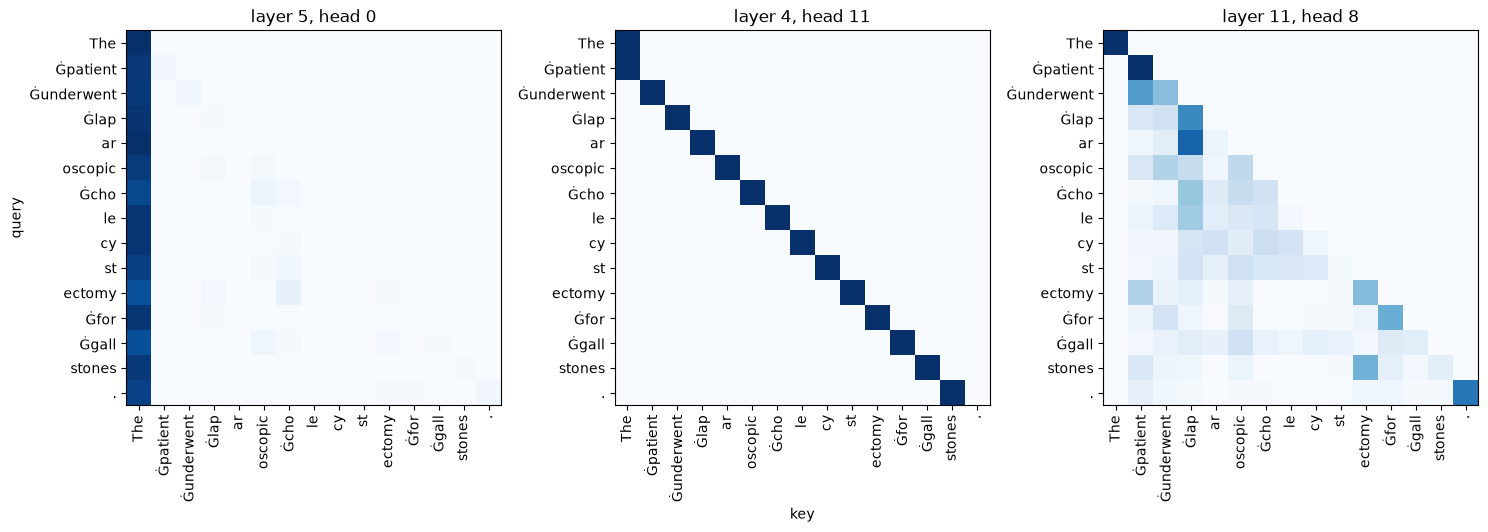

In [11]:
gpt2_tok = AutoTokenizer.from_pretrained("openai-community/gpt2")
viewer = AutoModel.from_pretrained("openai-community/gpt2", attn_implementation="eager")  # eager returns the weights
enc = gpt2_tok("The patient underwent laparoscopic cholecystectomy for gallstones.", return_tensors="pt")
with torch.no_grad():
    attentions = viewer(**enc, output_attentions=True).attentions   # per layer: (1, heads, n, n)
tokens = gpt2_tok.convert_ids_to_tokens(enc["input_ids"][0])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (layer, head) in zip(axes, [(5, 0), (4, 11), (11, 8)]):
    ax.imshow(attentions[layer][0, head], cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)), tokens, rotation=90); ax.set_yticks(range(len(tokens)), tokens)
    ax.set_title(f"layer {layer}, head {head}")
axes[0].set_ylabel("query"); axes[1].set_xlabel("key")
plt.tight_layout(); plt.show()

**Questions**
- Why is everything above the diagonal zero? Would it be with a BERT model?
- Each row sums to 1. Why does the first head send almost everything to `The`?
- What does the second head do? And in the third, which tokens does `stones` look at?

## 5. Explore the embedding space

Two notes are compared by the angle between their vectors, the **cosine similarity**
$\cos(a, b) = \frac{a \cdot b}{\lVert a \rVert\, \lVert b \rVert}$. Average the training
vectors of each specialty into a **centroid**, then classify a validation note by its most
similar centroid: no training at all.

nearest-centroid validation F1-macro: 0.202


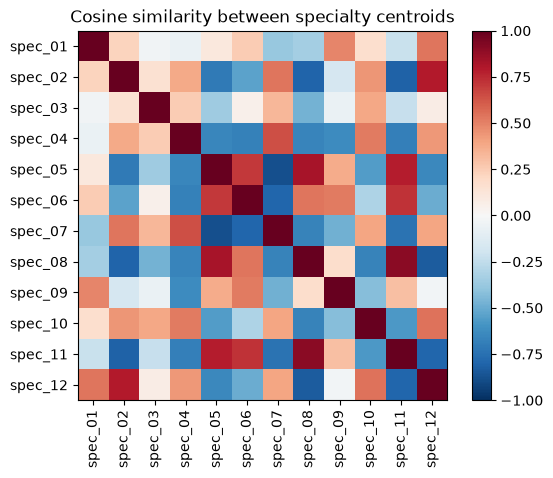

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

Z = X - X[idx_tr].mean(0)                # centre the cloud (see the questions)
centroids = np.stack([Z[idx_tr][y[idx_tr] == c].mean(0) for c in classes])
nearest = np.array(classes)[cosine_similarity(Z[idx_val], centroids).argmax(1)]
print("nearest-centroid validation F1-macro: %.3f" % f1_score(y[idx_val], nearest, average="macro"))

plt.imshow(cosine_similarity(centroids), cmap="RdBu_r", vmin=-1, vmax=1)
plt.xticks(range(12), classes, rotation=90); plt.yticks(range(12), classes)
plt.colorbar(); plt.title("Cosine similarity between specialty centroids"); plt.show()

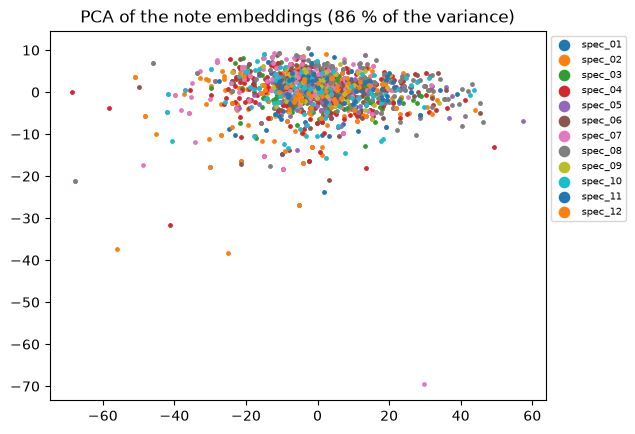

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(Z[idx_tr])
P = pca.transform(Z[idx_tr])
for c in classes:
    plt.scatter(*P[y[idx_tr] == c].T, s=6, label=c)
plt.legend(markerscale=3, fontsize=7, bbox_to_anchor=(1, 1))
plt.title("PCA of the note embeddings (%.0f %% of the variance)" % (100 * pca.explained_variance_ratio_.sum()))
plt.show()

**Questions**
- Print `cosine_similarity(X[:100]).mean()` on the raw, uncentred embeddings. What do you
  get, and why does it make raw cosine similarity useless here?
- Which specialties are closest to each other? Are they also the ones the baseline confuses?
- Do the specialties form clusters in the PCA plot? How much of the variance do these two
  axes keep?

## 6. An MLP on the embeddings

The pretrained model stays frozen; only a small classifier is trained on its vectors.

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

labels = LabelEncoder().fit(y)           # the MLP's early stopping needs integer labels
mlp = make_pipeline(StandardScaler(),
                    MLPClassifier(hidden_layer_sizes=(256,), alpha=1e-2, early_stopping=True,
                                  max_iter=500, random_state=0))
mlp.fit(X[idx_tr], labels.transform(y[idx_tr]))
pred = labels.inverse_transform(mlp.predict(X[idx_val]))
print("validation F1-macro: %.3f" % f1_score(y[idx_val], pred, average="macro"))

validation F1-macro: 0.554


Submit it once it beats your previous best on the validation split.

In [15]:
mlp.fit(X, labels.transform(y))
pd.DataFrame({"id": test["id"], "label": labels.inverse_transform(mlp.predict(X_test))}).to_csv("submission.csv", index=False)
client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"],
              submission_name=f"{MODEL_NAME.split('/')[-1]}-{POOLING}-mlp")

{'submission_id': 9102,
 'deploy': {'deployment_id': 8813,
  'is_deployable': False,
  'is_settled': False,
  'is_uploadable': False,
  'last_status_message': 'Deployment queued successfully',
  'message': 'Deployment started successfully',
  'phase': 'deployment',
  'status': 'deploy_queue',
  'status_update_ts': '2026-09-29T10:02:37.242859Z'}}

## 7. Best model: BGE embeddings + balanced SVM

The final cell retains only the selected model. [BGE-small's model card](https://huggingface.co/BAAI/bge-small-en-v1.5)
uses normalised CLS embeddings. This is a frozen 33.36M-parameter encoder with a
30,522-token vocabulary, trained for general-text retrieval. Its median training
note has 608 tokens. A balanced RBF SVM (`C=1`) classifies the embeddings.

### Why the earlier validation and test scores differed

The old MiniLM model scored **0.6033** on 391 validation notes but **0.5678** on
ML-Arena submission **9128**. We verified that the uploaded predictions matched
our exported file exactly; this was not a filename or prediction mix-up.

- **Small-split uncertainty:** five other stratified folds scored 0.574–0.617
  (pooled out-of-fold F1 0.5953). A validation-note bootstrap gave an approximate
  95% interval of 0.5566–0.6410. This excludes training and model-selection uncertainty.
- **Conflicting labels:** 424 distinct training texts occur under different labels,
  involving 875 rows. Text alone cannot distinguish those identical examples.
  The old model's out-of-fold F1 was 0.4114 on texts also seen in that fold's
  training partition, versus 0.6884 on unseen texts.
- **Different mixture of notes:** 223/488 test notes (45.7%) repeat training text,
  compared with 36.7% across validation folds. Resampling the old out-of-fold
  predictions to this test mixture yielded mean F1 about 0.569, close to 0.5678.
  This is a diagnostic inference, not proof of causality: hidden labels are unknown.
  Note lengths were similar (median 376 training / 391 test words).
- **Selection optimism:** we repeatedly checked the original split while improving
  the model. Clearing 0.60 there was not sufficient evidence of passing the test.
  Grouping identical notes together gives old-model F1 0.6256, so ordinary duplicate
  leakage does not explain the optimism here; the conflicting labels matter.

### Model choice and evaluation

| Frozen encoder + classifier | Pooling | Five-fold OOF macro F1 |
|---|---|---:|
| Previous MiniLM + balanced logistic | CLS, first 512 tokens | 0.5953 |
| PubMedBERT embeddings + balanced SVM | Mean, first 512 tokens | 0.6294 |
| BGE + balanced SVM, average of all chunks | CLS per chunk | 0.6243 |
| **BGE + balanced SVM, first 512 tokens** | **CLS** | **0.6435** |

For BGE, nested CV selected `C` from `[0.1, 0.3, 1, 3]` using only each outer
training fold. Every fold selected `C=1`: outer fold F1 scores were **0.6200,
0.6567, 0.6331, 0.6577, 0.6466**. Pooled nested OOF F1 was **0.6435**; grouped
fixed-C OOF F1 was **0.6654**. The original validation split scored **0.6381**.
The final cell reproduces fixed-C OOF evaluation, rather than rerunning the search.
Model-family selection still used these development data, so these are not new
independent test estimates.

Keeping all chunks did not help in this experiment. PubMedBERT keeps the example
medical words intact but did not beat BGE: medical vocabulary and greater size
alone do not guarantee better classification. BGE's weakest classes remain
`spec_01` (OOF F1 0.14) and `spec_07` (0.44), consistent with label ambiguity.
Test-mixture resampling estimated BGE F1 near 0.615, with substantial uncertainty;
only the platform can establish whether this submission passes 0.60.

**Submission:** `submission.csv` contains the selected model's 488 predictions.
**Verified ML-Arena test macro F1: 0.623077 (0.6231)**, exceeding the 0.60 target.
Submission **9137**, `bge-cls-balanced-svm`, completed successfully on 1 October 2026.
Previous submission: 0.567754; improvement: 0.055323 (5.53 F1 percentage points).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report

# Load the notes; this cell runs independently of Sections 0–6.
folder = Path(".") if Path("data/train.csv").exists() else Path("S7 NLP")
train = pd.read_csv(folder / "data/train.csv")
test = pd.read_csv(folder / "data/test.csv")
y = train["label"].to_numpy()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
torch.set_num_threads(4)
name = "BAAI/bge-small-en-v1.5"
cache = folder / ".hf_cache" / "hub"
tokenizer = AutoTokenizer.from_pretrained(name, cache_dir=cache)
model = AutoModel.from_pretrained(name, cache_dir=cache).to(device).eval()

@torch.inference_mode()
def embed(texts):
    # BGE uses the contextual CLS vector; keep the first 512 tokens of each note.
    vectors = []
    for start in range(0, len(texts), 16):
        batch = tokenizer(texts[start:start + 16], padding=True, truncation=True,
                          max_length=512, return_tensors="pt").to(device)
        vector = model(**batch).last_hidden_state[:, 0]
        vectors.append(torch.nn.functional.normalize(vector, dim=1).cpu().numpy())
    return np.vstack(vectors)

X = embed(train["transcription"].fillna("").tolist())
# C=1 won training-only nested CV; balancing gives rare specialties more weight.
classifier = make_pipeline(Normalizer(), SVC(C=1, class_weight="balanced"))
cv = StratifiedKFold(5, shuffle=True, random_state=42)
pred = cross_val_predict(classifier, X, y, cv=cv)
print(f"Five-fold out-of-fold macro F1: {f1_score(y, pred, average='macro'):.4f}")
print(classification_report(y, pred, zero_division=0))

# Also report the original split, before refitting on all labelled notes.
idx_tr, idx_val = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=0)
classifier.fit(X[idx_tr], y[idx_tr])
print(f"Original validation macro F1: {f1_score(y[idx_val], classifier.predict(X[idx_val]), average='macro'):.4f}")
X_test = embed(test["transcription"].fillna("").tolist())
classifier.fit(X, y)
submission = folder / "submission.csv"
pd.DataFrame({"id": test["id"], "label": classifier.predict(X_test)}).to_csv(submission, index=False)
print(f"Saved {len(test)} predictions to {submission}")

# Submit only when wanted, using client from Section 0:
# client.submit(challenge_id=174, files=[str(submission)], submission_name="bge-cls-balanced-svm")


Five-fold out-of-fold macro F1: 0.6435
              precision    recall  f1-score   support

     spec_01       0.32      0.09      0.14       280
     spec_02       0.70      0.64      0.67       280
     spec_03       0.72      0.81      0.76       178
     spec_04       0.73      0.76      0.74       280
     spec_05       0.71      0.86      0.78        77
     spec_06       0.76      0.92      0.83       124
     spec_07       0.46      0.41      0.44       217
     spec_08       0.58      0.67      0.62       178
     spec_09       0.74      0.97      0.84        66
     spec_10       0.71      0.85      0.77       124
     spec_11       0.52      0.65      0.58        72
     spec_12       0.41      0.87      0.56        75

    accuracy                           0.63      1951
   macro avg       0.61      0.71      0.64      1951
weighted avg       0.60      0.63      0.60      1951

Original validation macro F1: 0.6381
Saved 488 predictions to submission.csv
